#  Hotstar Content Analysis – Exploratory Data Analysis (EDA)



##  Introduction
In this notebook, we perform Exploratory Data Analysis (EDA) on Hotstar content data.  
The aim is to uncover insights related to genres, IMDB ratings, runtime, content type, and trends over time.

Objectives
- Identify dominant genres  
- Analyze IMDB rating patterns  
- Compare Movies vs TV Shows  
- Study runtime distribution  
- Explore release year trends  
- Extract meaningful business insights  



##  Importing Required Libraries


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview
Understanding the columns, datatypes, number of rows, and basic info.


In [3]:
df = pd.read_csv("hotstar.csv")
df

,hotstar_id,title,description,genre,year,age_rating,running_time,seasons,episodes,type
0,1000087439,Sambha - Aajcha Chawa,A young man sets off on a mission to clean up ...,Action,2012,U/A 16+,141.0,NaN,NaN,movie
1,1260023113,Cars Toon: Mater And The Ghostlight,Mater is haunted by a mysterious blue light th...,Animation,2006,U,7.0,NaN,NaN,movie
2,1260103188,Kanmani Rambo Khatija,"Unlucky since birth, Rambo finds hope when he ...",Romance,2022,U/A 16+,157.0,NaN,NaN,movie
3,1260126754,Butterfly,While trying to rescue her sister's kids from ...,Thriller,2022,U/A 16+,136.0,NaN,NaN,movie
4,1260018228,Sister Act,"Rene, a lounge singer, decides to stay at a Ch...",Comedy,1992,U/A 7+,100.0,NaN,NaN,movie
...,...,...,...,...,...,...,...,...,...,...
6869,1260127438,Will Trent,SHOW ON BREAK- NEXT EPISODE ON 15TH FEB. Speci...,Crime,2023,U/A 16+,NaN,1.0,5.0,tv
6870,1260008508,KBD Juniors - Qualifiers,Match highlights of Kabaddi Junior,Sport,2019,U,NaN,1.0,32.0,tv
6871,12551,Dil Hai Hindustani,Sway to the tunes of the best Hindi/Bollywood ...,Reality,2017,U/A 13+,NaN,2.0,57.0,tv
6872,1260065225,On The Brink,The series reveals the hidden splendours of In...,Animals & Nature,2021,U/A 7+,NaN,2.0,18.0,tv


In [4]:
df.head()

,hotstar_id,title,description,genre,year,age_rating,running_time,seasons,episodes,type
0,1000087439,Sambha - Aajcha Chawa,A young man sets off on a mission to clean up ...,Action,2012,U/A 16+,141.0,NaN,NaN,movie
1,1260023113,Cars Toon: Mater And The Ghostlight,Mater is haunted by a mysterious blue light th...,Animation,2006,U,7.0,NaN,NaN,movie
2,1260103188,Kanmani Rambo Khatija,"Unlucky since birth, Rambo finds hope when he ...",Romance,2022,U/A 16+,157.0,NaN,NaN,movie
3,1260126754,Butterfly,While trying to rescue her sister's kids from ...,Thriller,2022,U/A 16+,136.0,NaN,NaN,movie
4,1260018228,Sister Act,"Rene, a lounge singer, decides to stay at a Ch...",Comedy,1992,U/A 7+,100.0,NaN,NaN,movie


In [5]:
df.tail(3)

,hotstar_id,title,description,genre,year,age_rating,running_time,seasons,episodes,type
6871,12551,Dil Hai Hindustani,Sway to the tunes of the best Hindi/Bollywood ...,Reality,2017,U/A 13+,NaN,2.0,57.0,tv
6872,1260065225,On The Brink,The series reveals the hidden splendours of In...,Animals & Nature,2021,U/A 7+,NaN,2.0,18.0,tv
6873,1260129361,Mahanadhi,Tragedy befalls a happy middle-class family af...,Family,2023,U/A 13+,NaN,1.0,10.0,tv


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6874 entries, 0 to 6873
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hotstar_id    6874 non-null   int64  
 1   title         6874 non-null   object 
 2   description   6874 non-null   object 
 3   genre         6874 non-null   object 
 4   year          6874 non-null   int64  
 5   age_rating    6874 non-null   object 
 6   running_time  4568 non-null   float64
 7   seasons       2306 non-null   float64
 8   episodes      2306 non-null   float64
 9   type          6874 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 537.2+ KB


In [7]:
df.describe()

,hotstar_id,year,running_time,seasons,episodes
count,6.874000e+03,6874.000000,4568.000000,2306.000000,2306.000000
mean,1.059077e+09,2011.718650,98.746716,2.661752,127.366869
std,4.812666e+08,11.936894,49.411142,4.942716,258.138186
min,3.000000e+00,1928.000000,1.000000,1.000000,1.000000
25%,1.000088e+09,2009.000000,70.000000,1.000000,6.000000
50%,1.260008e+09,2016.000000,116.000000,1.000000,22.000000
75%,1.260099e+09,2019.000000,135.000000,2.000000,130.750000
max,1.837059e+09,2023.000000,229.000000,73.000000,3973.000000


In [8]:
df.isnull().sum()

,0
hotstar_id,0
title,0
description,0
genre,0
year,0
age_rating,0
running_time,2306
seasons,4568
episodes,4568
type,0


In [9]:
df['running_time']=df['running_time'].fillna(df['running_time'].median())

In [10]:
df.duplicated().sum()

np.int64(0)

###Movies vs TV Shows


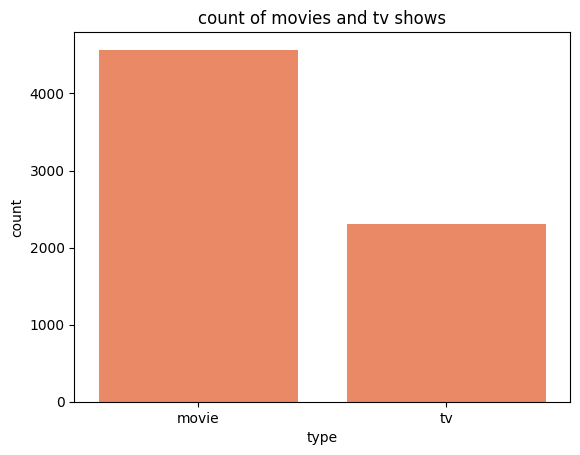

In [11]:
sns.countplot(x = df['type'],data=df,color="coral")
plt.title("count of movies and tv shows")
plt.show()

###Genre Distribution


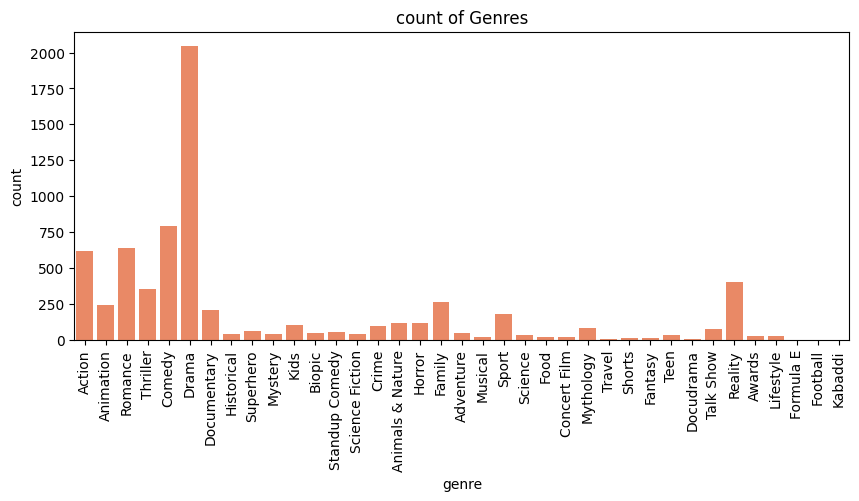

In [12]:
plt.figure(figsize=(10,4))
sns.countplot(x=df["genre"],data=df,color="coral")
plt.title("count of Genres")
plt.xticks(rotation=90)
plt.show()

In [13]:
gb=df.groupby("age_rating").agg({"hotstar_id":"count"})
gb

,hotstar_id
age_rating,
A,338
PG,1
U,1251
U/A 13+,2980
U/A 16+,1235
U/A 7+,1069


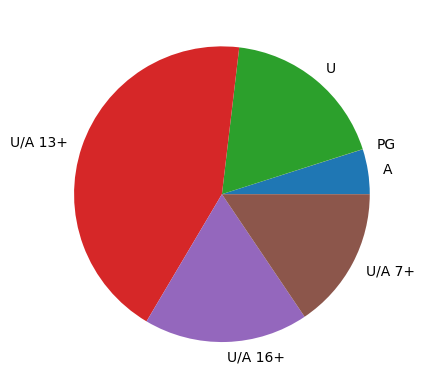

In [14]:
plt.pie(gb["hotstar_id"],labels = gb.index)
plt.show()

In [15]:
gb=df.groupby("year").agg({"hotstar_id":'count'})
gb

,hotstar_id
year,
1928,1
1937,1
1940,2
1941,5
1942,1
...,...
2019,498
2020,415
2021,561


### Release Year Trends


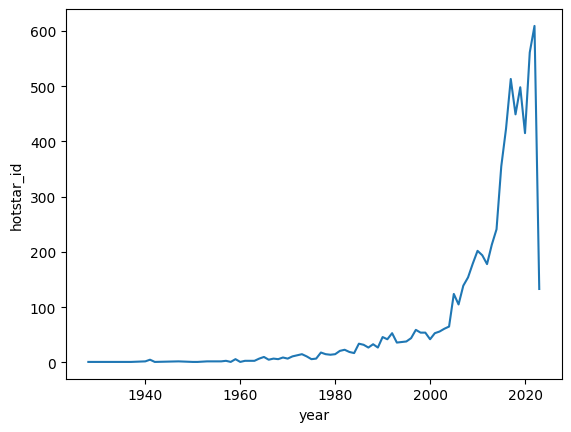

In [16]:
sns.lineplot(x=gb.index,y=gb["hotstar_id"])
plt.show()

In [17]:
df.columns


Index(['hotstar_id', 'title', 'description', 'genre', 'year', 'age_rating',
       'running_time', 'seasons', 'episodes', 'type'],
      dtype='object')

###Highest Runtime Movies

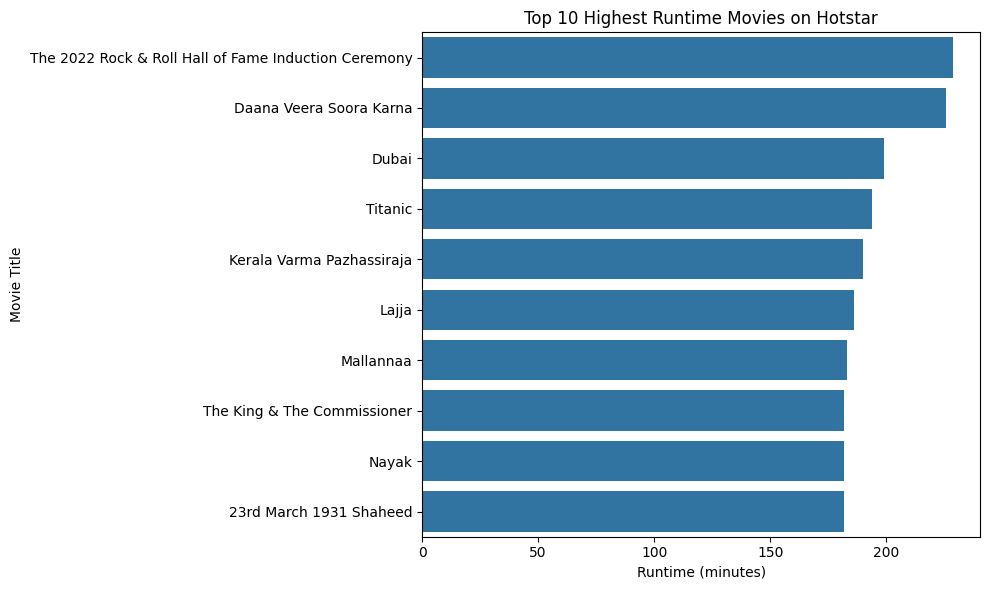

In [18]:
movies_df = df.loc[df['type'].str.lower() == 'movie'].copy()
# Convert runtime to string (using loc)
movies_df.loc[:, 'runtime_str'] = movies_df['running_time'].astype(str)

movies_df.loc[:, 'runtime_clean'] = movies_df['runtime_str'].str.extract(r'(\d+)')

movies_df.loc[:, 'runtime_clean'] = pd.to_numeric(movies_df['runtime_clean'], errors='coerce')

movies_df = movies_df.dropna(subset=['runtime_clean'])

top_runtime = movies_df.sort_values('runtime_clean', ascending=False).head(10)


plt.figure(figsize=(10, 6))
sns.barplot(data=top_runtime, y='title', x='runtime_clean')
plt.title('Top 10 Highest Runtime Movies on Hotstar')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


In [23]:
print(df['running_time'].describe())
print(df['type'].value_counts())
print(df[df['running_time'].notna()]['type'].value_counts())

count    6874.000000
mean      104.534623
std        41.093581
min         1.000000
25%       102.000000
50%       116.000000
75%       127.000000
max       229.000000
Name: running_time, dtype: float64
type
movie    4568
tv       2306
Name: count, dtype: int64
type
movie    4568
tv       2306
Name: count, dtype: int64


### Runtime Distribution by Type

Boxplot looks like a line → Because most running_time values belong to only one content type (usually movies). I show counts per type first and only plot types with enough samples so the boxplots are meaningful.

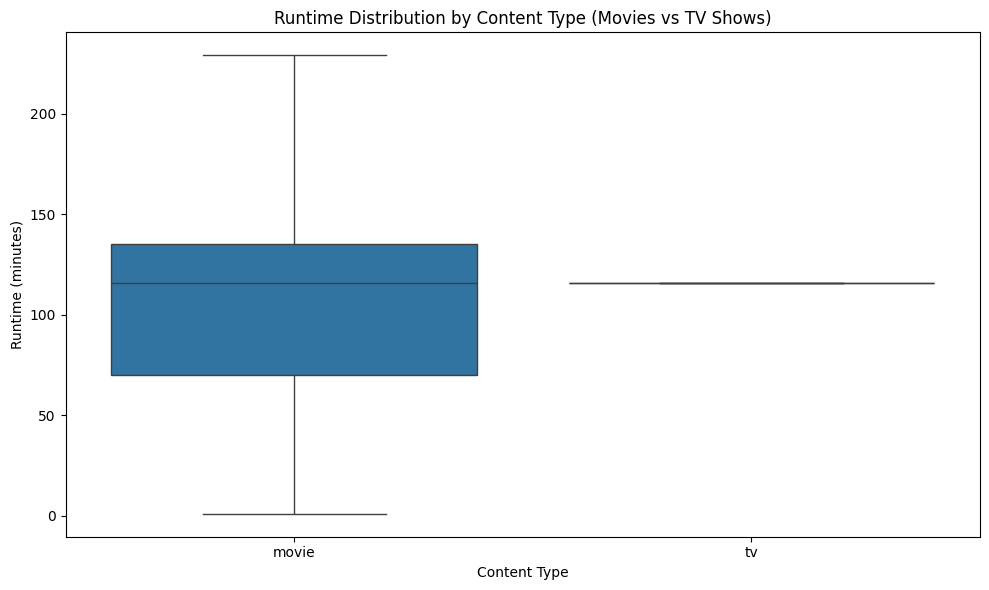

In [19]:
runtime_df = df.dropna(subset=['running_time']).copy()
runtime_df['type'] = runtime_df['type'].str.lower()

plt.figure(figsize=(10, 6))
sns.boxplot(data=runtime_df, x='type', y='running_time')
plt.title("Runtime Distribution by Content Type (Movies vs TV Shows)")
plt.xlabel("Content Type")
plt.ylabel("Runtime (minutes)")
plt.tight_layout()
plt.show()
